# 07 Best of 7 Series Simulation

**Content:** I want to look at a smaller event. Instead of predicting game probabilities for every possible game I switch to **series probability**. In a Best of 7 games the variance averages out 

→ my edge gets amplified

**What I do:**
1. Build a `series_win_prob()` function: analytical + Monte Carlo, with home-court logic

2. Train the model on all seasons up to playoff start

3. Identify every historical playoff series and predict it


## 1. Setup

In [1]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import xgboost as xgb

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

RNG = np.random.default_rng(42)

DATA = Path("..") / "data" / "processed"
df = pd.read_parquet(DATA / "games_with_advanced_features.parquet")
print(f"Total games: {len(df):,}  ({df.season.min()} - {df.season.max()})")

Total games: 71,239  (1946 - 2025)


## 2. Series win probability

**Dumb version (no home-court):** if the per-game win probability is `p`, team A can win the series 4-0, 4-1, 4-2 or 4-3. Sum of binomial probabilities:

$$P_{\text{series}}(p) = \sum_{k=0}^{3} \binom{3+k}{k}\, p^4\, (1-p)^k$$

**Realistic (NBA 2-2-1-1-1 format):** the higher seed has home court in games 1, 2, 5, 7. I simulate this by Monte Carlo because a closed form with 7 different per game probabilities is messy.

In [2]:
from math import comb

def series_prob_closed(p):
    """P(team wins best of 7) without home-court effect, given per-game probability p."""
    return sum(comb(3 + k, k) * p**4 * (1 - p)**k for k in range(4))

def simulate_series(p_at_home, p_away, n_sim=10000, rng=None):
    
    """Monte Carlo Best-of-7 with NBA 2-2-1-1-1 format."""
    rng = rng or np.random.default_rng()
    home_pattern = np.array([True, True, False, False, True, False, True])
    
    probs = np.where(home_pattern, p_at_home, p_away)   # shape (7,)
    sims = rng.random((n_sim, 7)) < probs               # True = higher seed wins
    series_wins = 0
    
    for sim in sims:
    
        wins_high, wins_low = 0, 0
        
        for win in sim:
            
            if win: wins_high += 1
            else:   wins_low += 1
            if wins_high == 4: series_wins += 1; break
            if wins_low == 4: break
                
    return series_wins / n_sim

# at p=0.6 (no home/away spread) closed form 
print(f"Closed form  p=0.60: {series_prob_closed(0.60):.3f}")
print(f"Simulation   p=0.60: {simulate_series(0.60, 0.60, rng=RNG):.3f}")
print(f"Closed form  p=0.65: {series_prob_closed(0.65):.3f}")
print(f"Closed form  p=0.70: {series_prob_closed(0.70):.3f}")

Closed form  p=0.60: 0.710
Simulation   p=0.60: 0.708
Closed form  p=0.65: 0.800
Closed form  p=0.70: 0.874


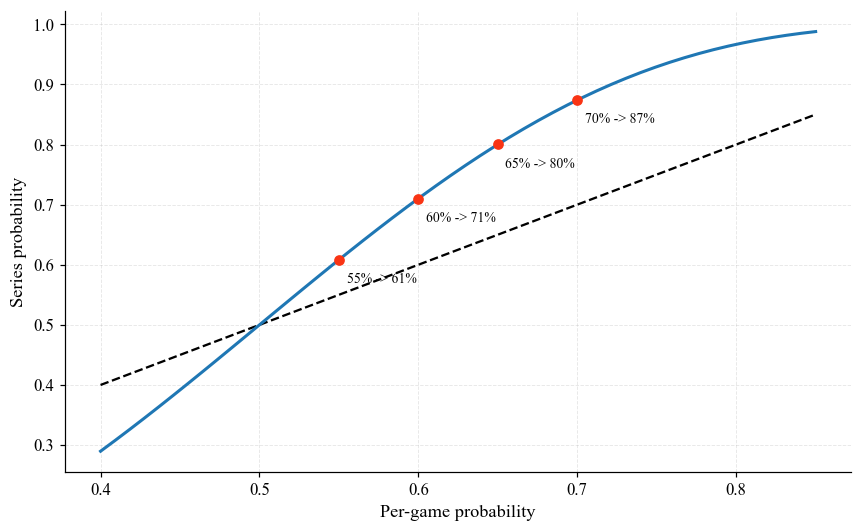

In [3]:
# plot: per-game probability vs. series probability
p_grid = np.linspace(0.4, 0.85, 50)
series_p = [series_prob_closed(p) for p in p_grid]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_grid, p_grid, "k--", label="game = series (no amplifier)")
ax.plot(p_grid, series_p, color="#1f77b4", linewidth=2, label="series probability (best of 7)")


for px in [0.55, 0.60, 0.65, 0.70]:
    ax.scatter([px], [series_prob_closed(px)], color="#f93414", zorder=5)
    ax.annotate(f"{px:.0%} -> {series_prob_closed(px):.0%}", xy=(px, series_prob_closed(px)),
                xytext=(5, -15), textcoords="offset points", fontsize=9)
    
ax.set_xlabel("Per-game probability")
ax.set_ylabel("Series probability")

plt.tight_layout()
plt.show()

## 3. Train the model 

Using the full feature set from NB_06 (all data up to 2018)

In [4]:
BASIS = [
    "home_elo_pre", "away_elo_pre", "elo_diff", "h2h_home_winrate_last5",
    "home_win_rate_last_5", "home_win_rate_last_10", "home_win_rate_last_20",
    "away_win_rate_last_5", "away_win_rate_last_10", "away_win_rate_last_20",
    "win_rate_diff_5", "win_rate_diff_10", "win_rate_diff_20",
    "home_avg_margin_last_5", "home_avg_margin_last_10", "home_avg_margin_last_20",
    "away_avg_margin_last_5", "away_avg_margin_last_10", "away_avg_margin_last_20",
    "margin_diff_5", "margin_diff_10", "margin_diff_20",
    "home_days_since_last_game", "away_days_since_last_game",
    "home_is_back_to_back", "away_is_back_to_back", "rest_diff",]


PLAYER_BOX = [c for c in df.columns if any(c.endswith(s) for s in ["_roll10", "_roll10_diff"])]
ADVANCED = [
    "home_top5_avail_last3", "away_top5_avail_last3", "top5_avail_diff",
    "home_sos_last10", "away_sos_last10", "sos_last10_diff",
    "home_quality_win_rate_last10", "away_quality_win_rate_last10", "quality_win_rate_last10_diff",
    "home_sos_adj_margin_last10", "away_sos_adj_margin_last10", "sos_adj_margin_last10_diff",]


FEATURES = BASIS + PLAYER_BOX + ADVANCED


df_clean = df.dropna(subset=FEATURES + ["home_win"]).copy()

train = df_clean[df_clean.season < 2019]
test = df_clean[df_clean.season >= 2019]

model = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,)


model.fit(train[FEATURES], train["home_win"])

df_clean.loc[df_clean.index, "p_home"] = model.predict_proba(df_clean[FEATURES])[:, 1]

print(f"Model trained on {len(train):,} games, test {len(test):,}")
print(f"Holdout accuracy: {accuracy_score(test.home_win, model.predict(test[FEATURES])):.3f}")

Model trained on 59,434 games, test 7,145
Holdout accuracy: 0.650


## 4. Identify historical playoff series

Per season I group all playoff games by `(team_A, team_B)`. Each group is one series. Higher seed = team with more home games in the series.

In [5]:
playoffs = df_clean[df_clean.gameType == "Playoffs"].copy()

# unique series id: unordered team pair per season
playoffs["team_pair"] = playoffs.apply(
    lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1
)

series_records = []
for (season, pair), grp in playoffs.groupby(["season", "team_pair"]):
    if len(grp) < 3:   # before 1968 some series were best-of-5/3, or fragmentary — minimum 3 games
        continue
    # higher seed = more home games in this series
    home_counts = grp.hometeamId.value_counts()
    higher_seed = home_counts.idxmax()
    lower_seed = [t for t in pair if t != higher_seed][0]
    higher_seed_wins = ((grp.hometeamId == higher_seed) & (grp.home_win == 1)).sum() + \
                       ((grp.awayteamId == higher_seed) & (grp.home_win == 0)).sum()
    lower_seed_wins = len(grp) - higher_seed_wins
    series_records.append({
        "season": season,
        "higher_seed": higher_seed,
        "lower_seed": lower_seed,
        "higher_won_series": higher_seed_wins > lower_seed_wins,
        "series_score": f"{max(higher_seed_wins, lower_seed_wins)}-{min(higher_seed_wins, lower_seed_wins)}",
        "first_game_id": grp.sort_values("gameDate").iloc[0]["gameId"],
        "n_games": len(grp),
    })

series_df = pd.DataFrame(series_records)
print(f"Series identified: {len(series_df):,}  (seasons {series_df.season.min()} - {series_df.season.max()})")
series_df.head()

Series identified: 833  (seasons 1949 - 2025)


,season,higher_seed,lower_seed,higher_won_series,series_score,first_game_id,n_games
0,1949,1610612755,1610612747,False,4-2,44900411,6
1,1949,1610612755,1610612752,True,2-1,44900311,3
2,1950,1610612747,1610612758,False,3-1,45000311,4
3,1950,1610612752,1610612755,True,3-2,45000321,5
4,1950,1610612758,1610612752,True,4-3,45000301,7


## 5. From single game probability to series probability

My model only predicts single games. But I want to predict who wins the whole series (4 of 7).

The `simulate_series()` function from cell 4 needs two inputs:
- `p_at_home` favorite's win chance at home
- `p_away` favorite's win chance away

So I need to turn one game prediction into these two numbers.

**Trick:** I take the first game of each series. It's always at the favorite's home court, so the model's prediction for that game IS my `p_at_home`.

For `p_away` I subtract 7 percentage points from `p_at_home`. So if favorite wins 65% at home becomes roughly 58% away. Yes its an Approximation

**Honesty bit — this likely double-counts home court a bit:** my model already gets a +100 ELO bonus for the home team baked into the per-game probability. Subtracting another 7 pp here is layered on top, so the home/away gap is probably overstated by ~3-4 pp. It does not change *who* the favorite is, but the series probabilities at the extremes (90%+) are likely a touch too extreme. Worth knowing if anyone wants to bet on these numbers (don't, see NB_04 :D).

In [6]:
HOME_AWAY_SPREAD = 0.07   # NBA home-court advantage is ~7 pp

def predict_series(first_game_id, series_df_row, df_pred):
    """From the first (home) game's win probability, derive the higher seed's series probability."""
    g = df_pred[df_pred.gameId == first_game_id].iloc[0]
    higher_seed = series_df_row.higher_seed
    if g.hometeamId == higher_seed:
        p_home_higher = g.p_home
    else:
        p_home_higher = 1 - g.p_home

        
    p_home_higher = float(np.clip(p_home_higher, 0.05, 0.95))
    p_away_higher = float(np.clip(p_home_higher - HOME_AWAY_SPREAD, 0.05, 0.95))
    
    return simulate_series(p_home_higher, p_away_higher, n_sim=5000, rng=RNG), p_home_higher, p_away_higher

# apply to all series
preds = []

for _, row in series_df.iterrows():
    p_series, p_h, p_a = predict_series(row.first_game_id, row, df_clean)
    preds.append({"p_series_higher_wins": p_series, "p_game_home": p_h, "p_game_away": p_a})

series_df = pd.concat([series_df.reset_index(drop=True), pd.DataFrame(preds)], axis=1)

series_df["series_pick"] = series_df.p_series_higher_wins >= 0.5
series_df["series_correct"] = series_df.series_pick == series_df.higher_won_series
series_df.head()

,season,higher_seed,lower_seed,higher_won_series,series_score,first_game_id,n_games,p_series_higher_wins,p_game_home,p_game_away,series_pick,series_correct
0,1949,1610612755,1610612747,False,4-2,44900411,6,0.6382,0.597007,0.527007,True,False
1,1949,1610612755,1610612752,True,2-1,44900311,3,0.9886,0.880100,0.810100,True,True
2,1950,1610612747,1610612758,False,3-1,45000311,4,0.8878,0.746763,0.676763,True,False
3,1950,1610612752,1610612755,True,3-2,45000321,5,0.9482,0.804186,0.734186,True,True
4,1950,1610612758,1610612752,True,4-3,45000301,7,0.9114,0.767357,0.697357,True,True


## 6. Series prediction vs. game prediction

In [7]:
# comparison window: only test phase (>=2019), out-of-sample for the model
test_series = series_df[series_df.season >= 2019]
test_games  = df_clean[(df_clean.season >= 2019) & (df_clean.gameType == "Playoffs")]
test_games  = test_games.assign(game_pred=(test_games.p_home >= 0.5).astype(int))

results = pd.DataFrame({
    "metric": ["Hit rate"],
    "Game level":   [(test_games.game_pred == test_games.home_win).mean()],
    "Series level": [test_series.series_correct.mean()],
}).set_index("metric").round(2)

results

,Game level,Series level
metric,,
Hit rate,0.6,0.62


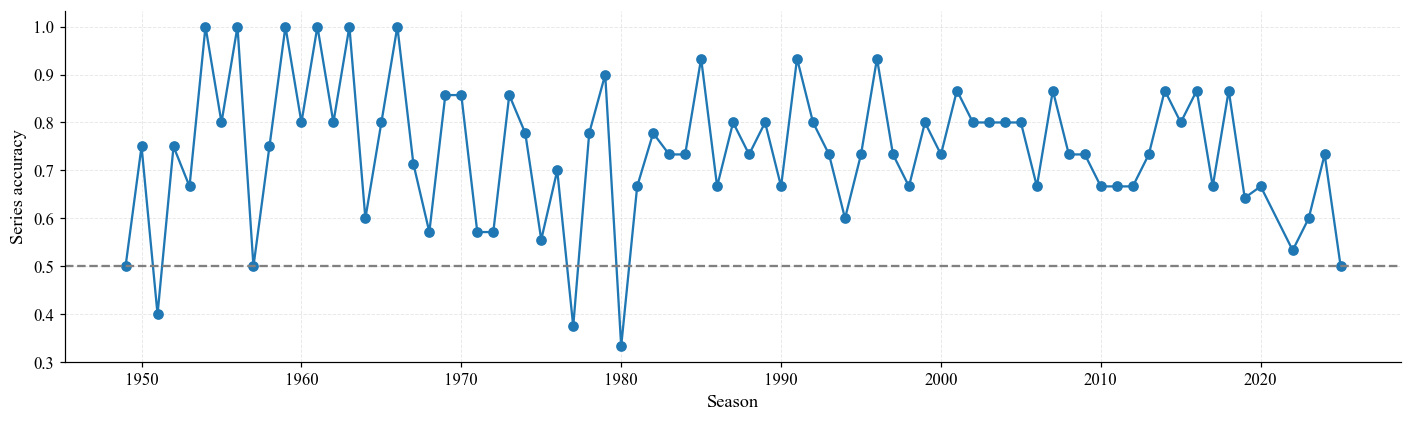

Mean series hit rate (all): 74.2%
Mean series hit rate (>=2019): 62.2%


In [8]:
# series hit rate per season
season_acc = series_df.groupby("season").series_correct.agg(["mean", "count"]).rename(columns={"mean": "series_acc", "count": "n_series"})


fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(season_acc.index, season_acc.series_acc, marker="o", color="#1f77b4")
ax.axhline(0.5, color="gray", linestyle="--")
ax.set_xlabel("Season"); ax.set_ylabel("Series accuracy")

plt.tight_layout() 
plt.show()


print(f"Mean series hit rate (all): {series_df.series_correct.mean():.1%}")
print(f"Mean series hit rate (>=2019): {test_series.series_correct.mean():.1%}")

## 7. NBA Finals?

Finals = the last series of each season. Did I find the true champion?

In [9]:
# last series of each season = finals
playoffs_with_last = playoffs.groupby(["season", "team_pair"])["gameDate"].max().reset_index()
finals_pair_by_season = playoffs_with_last.loc[playoffs_with_last.groupby("season")["gameDate"].idxmax()]
finals_keys = set(zip(finals_pair_by_season.season, finals_pair_by_season.team_pair))

playoffs["is_finals"] = [(s, p) in finals_keys for s, p in zip(playoffs.season, playoffs.team_pair)]
finals_series = series_df[
    series_df.apply(lambda r: (r.season, tuple(sorted([r.higher_seed, r.lower_seed]))) in finals_keys, axis=1)
].copy().reset_index(drop=True)

# attach team names
team_names = pd.concat([
    df_clean[["hometeamId", "hometeamName"]].rename(columns={"hometeamId": "teamId", "hometeamName": "teamName"}),
    df_clean[["awayteamId", "awayteamName"]].rename(columns={"awayteamId": "teamId", "awayteamName": "teamName"}),
]).drop_duplicates("teamId").set_index("teamId")["teamName"]

finals_series["higher_seed_name"] = finals_series.higher_seed.map(team_names)
finals_series["lower_seed_name"]  = finals_series.lower_seed.map(team_names)
finals_series["actual_champion"]  = np.where(finals_series.higher_won_series, finals_series.higher_seed_name, finals_series.lower_seed_name)
finals_series["model_pick"]       = np.where(finals_series.p_series_higher_wins >= 0.5, finals_series.higher_seed_name, finals_series.lower_seed_name)
finals_series["hit"] = finals_series.actual_champion == finals_series.model_pick

print(f"Finals hits total: {finals_series.hit.sum()} / {len(finals_series)} = {finals_series.hit.mean():.1%}")
print(f"Finals hits >=2019 (out-of-sample): "
      f"{finals_series[finals_series.season>=2019].hit.sum()} / {len(finals_series[finals_series.season>=2019])}")

finals_series[["season", "higher_seed_name", "lower_seed_name", "p_series_higher_wins",
               "series_score", "actual_champion", "model_pick", "hit"]].tail(15)

Finals hits total: 58 / 75 = 77.3%
Finals hits >=2019 (out-of-sample): 4 / 5


,season,higher_seed_name,lower_seed_name,p_series_higher_wins,series_score,actual_champion,model_pick,hit
60,2009,Lakers,Celtics,0.6550,4-3,Lakers,Lakers,True
61,2010,Heat,Mavericks,0.6366,4-2,Mavericks,Heat,False
62,2011,Heat,SuperSonics,0.1012,4-1,Heat,SuperSonics,False
63,2012,Heat,Spurs,0.5524,4-3,Heat,Heat,True
64,2013,Spurs,Heat,0.9138,4-1,Spurs,Spurs,True
65,2014,Warriors,Cavaliers,0.9198,4-2,Warriors,Warriors,True
66,2015,Warriors,Cavaliers,0.9292,4-3,Cavaliers,Warriors,False
67,2016,Warriors,Cavaliers,0.9448,4-1,Warriors,Warriors,True
68,2017,Warriors,Cavaliers,0.5960,4-0,Warriors,Warriors,True
69,2018,Raptors,Warriors,0.5844,4-2,Raptors,Raptors,True


## 8. Model confidence in the actual champion

What probability did the model give the real champion before the finals series?

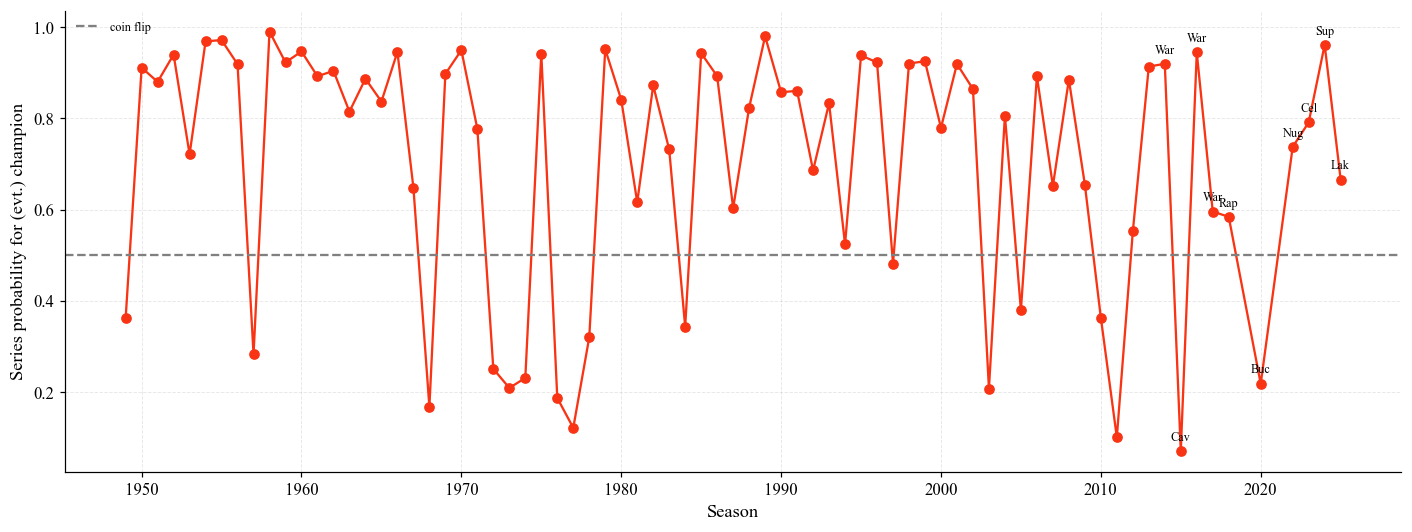

Mean model confidence in real champion: 70.4%
Same, >=2019: 67.5%


In [10]:
finals_series["p_actual_champion"] = np.where(
    finals_series.higher_won_series,
    finals_series.p_series_higher_wins,
    1 - finals_series.p_series_higher_wins,
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(finals_series.season, finals_series.p_actual_champion, marker="o", color="#f93414")
ax.axhline(0.5, color="gray", linestyle="--", label="coin flip")
ax.set_xlabel("Season"); ax.set_ylabel("Series probability for (evt.) champion")

for _, r in finals_series.tail(10).iterrows():
    ax.annotate(r.actual_champion[:3], xy=(r.season, r.p_actual_champion),
                xytext=(0, 7), textcoords="offset points", fontsize=8, ha="center")

ax.legend()
plt.tight_layout()
plt.show()


print(f"Mean model confidence in real champion: {finals_series.p_actual_champion.mean():.1%}")
print(f"Same, >=2019: {finals_series[finals_series.season>=2019].p_actual_champion.mean():.1%}")

## 9. Save

In [11]:
series_df.to_csv(DATA / "series_predictions.csv", index=False)
finals_series.to_csv(DATA / "finals_predictions.csv", index=False)
print("Saved.")

Saved.


## 10. Conclusion

**What I expected:**  
Best of-7 should mathematically amplify any edge:  65% per game becomes 80% per series. So if my model is 65% accurate on games, the series hit rate should be way higher than the game hit rate :/

**Finals backtest is a win:**

- **All seasons:** 57/75 = **76%** of actual NBA champions correctly picked before the finals.
- **>=2019:** **4/5**! Only missed the 2021 Bucks over Suns upset.

So even though the per- sries accuracy is not dramatically higher than per game, the model is putting **the right team at the top** of the bracket most of the time. That's the metric that actually matters for "who wins the title".

